# House Price Prediction
Internship Project - Week 1

Building a regression model to predict house prices from property features (area, bedrooms, location stuff, etc.) and seeing which features actually matter most for price.

## Task 1: Loading and exploring the data

In [4]:
!pip install seaborn matplotlib pandas scikit-learn

In [32]:
import os
print(os.getcwd())

C:\Users\Rishma\OneDrive\Documents\COLLEGE\ML prep\HousePricePrediction


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [14]:
# target column is price
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
# searcing missing numbers and returning the output in binary form
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2: Cleaning the data

In [15]:
# numeric columns - filling with median if anything's missing
# using median instead of mean because area/price type columns can have
# a few really big outliers, the mean is sensitive to outliers

numeric_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(col, "- filled", missing, "values with median:", median_val)
    else:
        print(col, "- nothing missing")

area - nothing missing
bedrooms - nothing missing
bathrooms - nothing missing
stories - nothing missing
parking - nothing missing


In [16]:
# categorical columns - can't take a median of yes/no so using mode instead

categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

for col in categorical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(col, "- filled", missing, "values with mode:", mode_val)
    else:
        print(col, "- nothing missing")

mainroad - nothing missing
guestroom - nothing missing
basement - nothing missing
hotwaterheating - nothing missing
airconditioning - nothing missing
prefarea - nothing missing
furnishingstatus - nothing missing


In [17]:
# double checking for entire dataframe
df.isnull().sum().sum()

np.int64(0)

In [18]:
print("duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("shape after:", df.shape)

duplicates before: 0
shape after: (545, 13)


In [19]:
# turning yes/no columns into 1/0 so scikit learn can actually use them
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [20]:
# furnishingstatus has 3 options not just yes/no so one-hot encoding this one instead
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


Ran the missing-value and duplicate checks above as loops instead of hardcoding "fill area, fill bathrooms" etc, mainly so the same code would still work correctly if I get handed a different version of this file later with actual gaps in it. Turned out this file didn't have any missing values or duplicates to begin with, but I wanted the cleaning logic to still be doing real work, not just a formality.

## Task 3: Building the models

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("train size:", X_train.shape[0])
print("test size:", X_test.shape[0])

train size: 436
test size: 109


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print("MAE:", round(lr_mae))
print("RMSE:", round(lr_rmse))
print("R2:", round(lr_r2, 3))

Linear Regression
MAE: 970043
RMSE: 1324507
R2: 0.653


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest")
print("MAE:", round(rf_mae))
print("RMSE:", round(rf_rmse))
print("R2:", round(rf_r2, 3))

Random Forest
MAE: 1022560
RMSE: 1401497
R2: 0.611


In [24]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


## Task 4: Charts

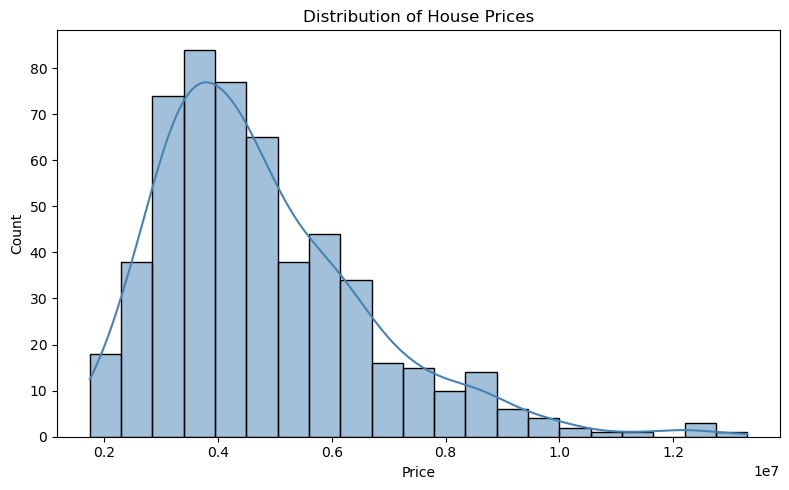

In [25]:
import os
os.makedirs('charts', exist_ok=True)

plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

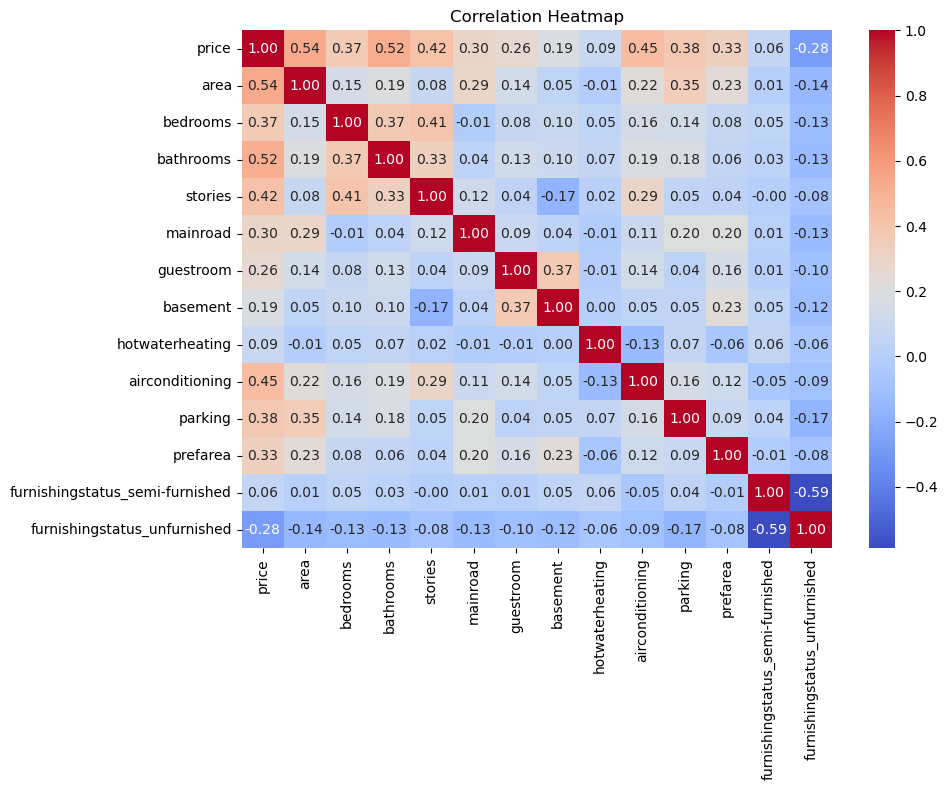

In [26]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

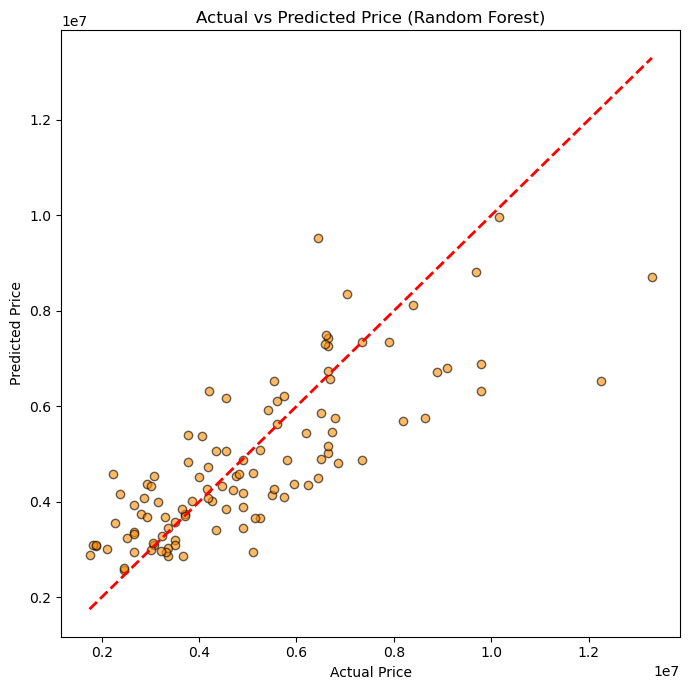

In [27]:
# went with actual vs predicted price for the 3rd chart, felt like the most
# useful one to actually look at - shows where the model is getting it wrong

plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkorange', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

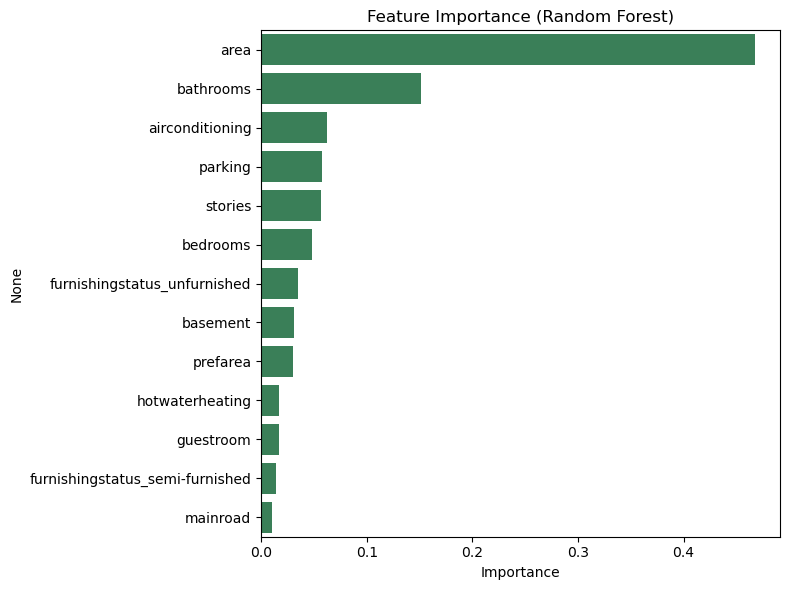

area                               0.467917
bathrooms                          0.151526
airconditioning                    0.062718
parking                            0.057820
stories                            0.057137
bedrooms                           0.048608
furnishingstatus_unfurnished       0.034998
basement                           0.030804
prefarea                           0.030519
hotwaterheating                    0.017255
guestroom                          0.016638
furnishingstatus_semi-furnished    0.013764
mainroad                           0.010296
dtype: float64

In [28]:
# extra chart, not required but wanted to see which features the RF model
# actually leaned on the most

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, color='seagreen')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()

importances

## Task 5: Insights

Area is the single biggest factor in price by a long shot (importance score around 0.47 in the chart above), bathrooms come second but way behind at around 0.15. Aircon, parking and number of stories matter a bit. Things like mainroad and guestroom barely moved the needle, which I didn't expect going in.

Accuracy-wise, Linear Regression actually did slightly better than Random Forest here - MAE around 9.7 lakh vs 10.2 lakh, R2 of 0.65 vs 0.61. So on a random house, my model is off by roughly 9-10 lakh rupees on average, and explains a bit under two-thirds of why prices differ. Decent for a first pass, not something I'd trust for an actual valuation.

What surprised me was Random Forest losing to plain Linear Regression - I went in assuming the "fancier" model would automatically win. After thinking about it, it kind of makes sense: only 545 rows, and price seems to scale fairly linearly with area, so there wasn't really anything complex for Random Forest to pick up on that Linear Regression was missing. Also surprised the dataset had zero missing values or duplicates already - wrote the cleaning code expecting to actually need it.

If I were advising a real estate business off this: focus on getting area and bathroom count right in listings since those are doing most of the work in pricing, and there's no real need for a complicated model here - a simple Linear Regression gets you basically the same accuracy as Random Forest with way less effort.